In [13]:
# Importing pandas for data manipulation
import pandas as pd

# Importing matplotlib for basic charts
import matplotlib.pyplot as plt

# Importing seaborn for beautiful charts
import seaborn as sns

# Importing os for folder creation
import os

# Setting seaborn style for all charts
sns.set_theme(style='whitegrid')

print("Libraries imported successfully ✅")

Libraries imported successfully ✅


In [14]:
# Loading the CO2 dataset
co2 = pd.read_csv('data/data.csv')

# Loading the Nepal disaster dataset
disasters = pd.read_excel('data/nepal_disasters.xlsx')

# Quick look at CO2 data
print("CO2 Dataset Shape:", co2.shape)
print(co2.head(3))

# Quick look at disaster data
print("\nDisaster Dataset Shape:", disasters.shape)
print(disasters.head(3))

CO2 Dataset Shape: (50411, 79)
       country  year iso_code  population  gdp  cement_co2  \
0  Afghanistan  1750      AFG   2802560.0  NaN         0.0   
1  Afghanistan  1751      AFG         NaN  NaN         0.0   
2  Afghanistan  1752      AFG         NaN  NaN         0.0   

   cement_co2_per_capita  co2  co2_growth_abs  co2_growth_prct  ...  \
0                    0.0  NaN             NaN              NaN  ...   
1                    NaN  NaN             NaN              NaN  ...   
2                    NaN  NaN             NaN              NaN  ...   

   share_global_other_co2  share_of_temperature_change_from_ghg  \
0                     NaN                                   NaN   
1                     NaN                                   NaN   
2                     NaN                                   NaN   

   temperature_change_from_ch4  temperature_change_from_co2  \
0                          NaN                          NaN   
1                          NaN          

In [15]:
# Checking disaster types in Nepal
print("Disaster Types:")
print(disasters['Disaster Type'].value_counts())

print("\nKey columns preview:")
print(disasters[['Start Year', 'Disaster Type', 'Disaster Subtype', 
                  'Total Deaths', 'No. Affected', 
                  'Total Damage (\'000 US$)']].head(10))

Disaster Types:
Disaster Type
Flood                          38
Mass movement (wet)            17
Epidemic                       10
Extreme temperature             7
Earthquake                      7
Storm                           6
Drought                         3
Glacial lake outburst flood     2
Wildfire                        1
Name: count, dtype: int64

Key columns preview:
   Start Year        Disaster Type  Disaster Subtype  Total Deaths  \
0        2026                Storm  Tropical cyclone          63.0   
1        2019                Storm    Severe weather          28.0   
2        2017                Flood   Flood (General)         176.0   
3        2022                Flood   Flood (General)          15.0   
4        2016                Flood   Flood (General)          25.0   
5        2015  Mass movement (wet)   Landslide (wet)          36.0   
6        2024                Flood   Flood (General)          24.0   
7        2024  Mass movement (wet)   Landslide (wet)    

In [16]:
# Filtering only flood related disasters
floods = disasters[disasters['Disaster Type'] == 'Flood'].copy()

# Also include landslides — caused by same climate patterns
landslides = disasters[disasters['Disaster Type'] == 'Mass movement (wet)'].copy()

# Combining floods and landslides
nepal_disasters = pd.concat([floods, landslides])

print("Flood records:", len(floods))
print("Landslide records:", len(landslides))
print("Total records:", len(nepal_disasters))

# Cleaning CO2 data — Nepal only
nepal_co2 = co2[co2['country'] == 'Nepal'][['year', 'co2', 'co2_per_capita']].dropna()
print("\nNepal CO2 records:", len(nepal_co2))

# Cleaning CO2 data — Global
co2_clean = co2[co2['year'] >= 2000]
global_avg = co2_clean.groupby('year')['co2_per_capita'].mean().reset_index()
print("Global average records:", len(global_avg))

Flood records: 38
Landslide records: 17
Total records: 55

Nepal CO2 records: 75
Global average records: 25


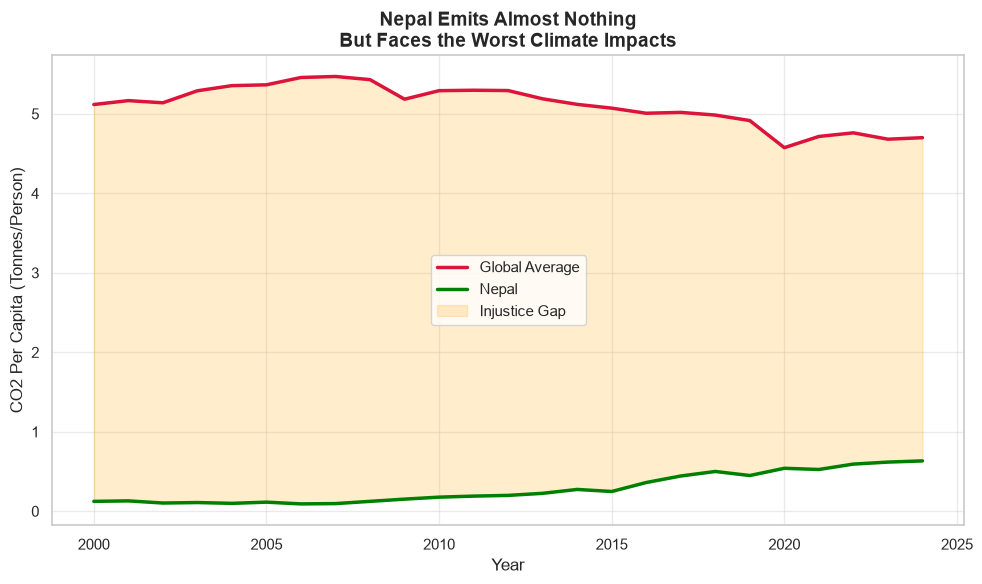

In [17]:
# Creating visuals folder
os.makedirs('visuals', exist_ok=True)

# CHART 1 — Nepal CO2 vs Global Average Per Capita
fig, ax = plt.subplots(figsize=(10, 6))

# Global average line
ax.plot(global_avg['year'], global_avg['co2_per_capita'],
        color='crimson', linewidth=2.5, label='Global Average')

# Nepal line
nepal_co2_filtered = nepal_co2[nepal_co2['year'] >= 2000]
ax.plot(nepal_co2_filtered['year'], nepal_co2_filtered['co2_per_capita'],
        color='green', linewidth=2.5, label='Nepal')

# Fill the gap
ax.fill_between(nepal_co2_filtered['year'],
                nepal_co2_filtered['co2_per_capita'],
                global_avg['co2_per_capita'],
                alpha=0.2, color='orange',
                label='Injustice Gap')

ax.set_title("Nepal Emits Almost Nothing\nBut Faces the Worst Climate Impacts",
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('CO2 Per Capita (Tonnes/Person)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('visuals/nepal_vs_world_co2.png', dpi=150)
plt.show()

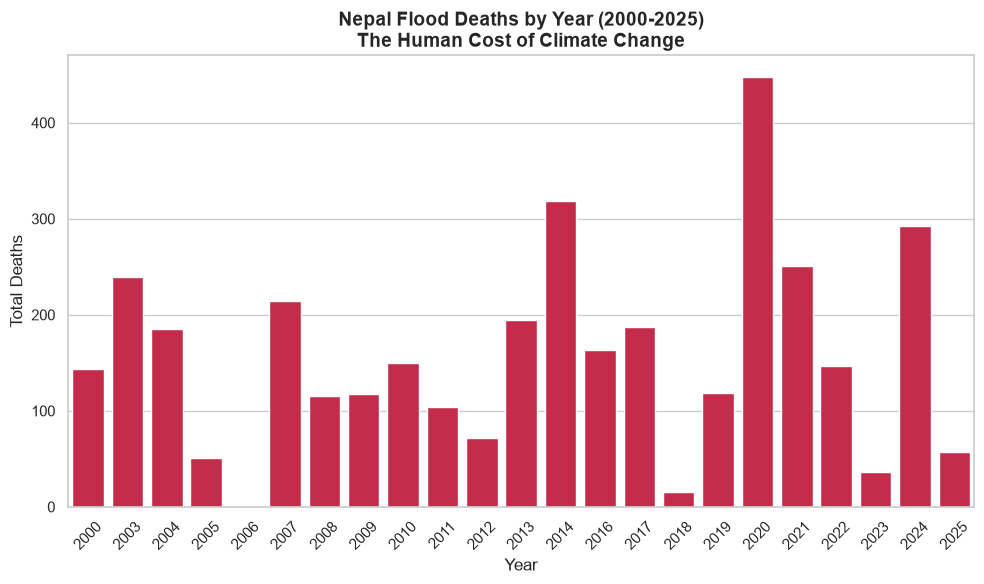

In [18]:
# CHART 2 — Nepal Flood Deaths by Year
flood_deaths = floods.groupby('Start Year')['Total Deaths'].sum().reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(data=flood_deaths, x='Start Year', 
            y='Total Deaths', color='crimson', ax=ax)

ax.set_title('Nepal Flood Deaths by Year (2000-2025)\nThe Human Cost of Climate Change',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Total Deaths', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visuals/flood_deaths.png', dpi=150)
plt.show()

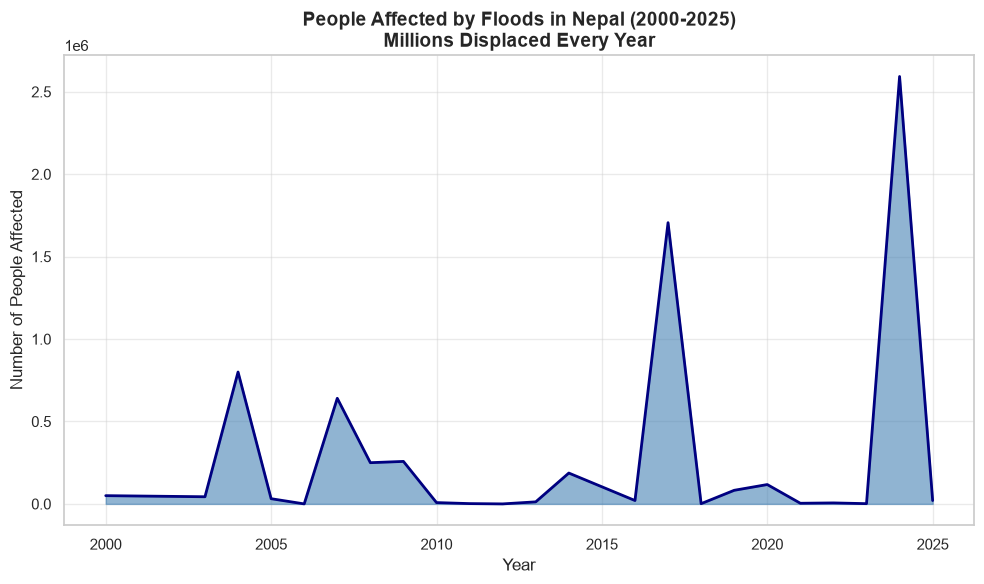

In [19]:
# CHART 3 — People Affected by Floods
flood_affected = floods.groupby('Start Year')['No. Affected'].sum().reset_index()
flood_affected = flood_affected.dropna()

fig, ax = plt.subplots(figsize=(10, 6))

ax.fill_between(flood_affected['Start Year'],
                flood_affected['No. Affected'],
                alpha=0.6, color='steelblue')
ax.plot(flood_affected['Start Year'],
        flood_affected['No. Affected'],
        color='navy', linewidth=2)

ax.set_title('People Affected by Floods in Nepal (2000-2025)\nMillions Displaced Every Year',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of People Affected', fontsize=12)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('visuals/flood_affected.png', dpi=150)
plt.show()

C:\Users\baibh\AppData\Local\Temp\ipykernel_15300\220835864.py:39: UserWarning: Glyph 127475 (\N{REGIONAL INDICATOR SYMBOL LETTER N}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\baibh\AppData\Local\Temp\ipykernel_15300\220835864.py:40: UserWarning: Glyph 127475 (\N{REGIONAL INDICATOR SYMBOL LETTER N}) missing from font(s) Arial.
  plt.savefig('visuals/top_emitters_vs_nepal.png', dpi=150)
c:\Users\baibh\OneDrive\Desktop\climate-justice-analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 127475 (\N{REGIONAL INDICATOR SYMBOL LETTER N}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


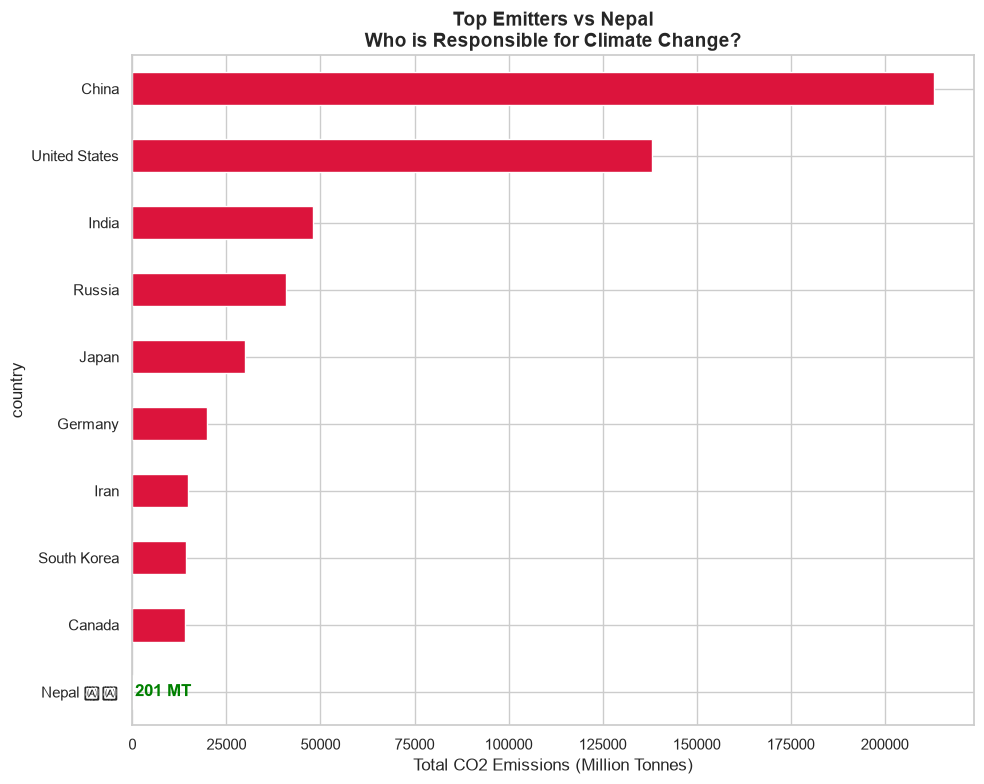

In [20]:
# Recreating co2_clean2
co2_clean2 = co2[co2['year'] >= 2000]

# Stronger filter + Nepal visibility fix
co2_countries2 = co2_clean2[~co2_clean2['country'].str.contains(
    'excl|GCP|income|OECD|European Union|Middle East|World|'
    'Asia|Europe|Africa|Oceania|America|Antarctica|transport',
    case=False
)]

# Top 10 real countries
top10 = co2_countries2.groupby('country')['co2'].sum()
top10 = top10.sort_values(ascending=False).head(10)
top10 = top10.drop('International shipping', errors='ignore')

# Nepal total
nepal_total = co2_countries2[co2_countries2['country'] == 'Nepal']['co2'].sum()

# Combine
comparison = top10.copy()
comparison['Nepal 🇳🇵'] = nepal_total
comparison = comparison.sort_values(ascending=True)

# Colors
colors = ['green' if x == 'Nepal 🇳🇵' else 'crimson'
          for x in comparison.index]

fig, ax = plt.subplots(figsize=(10, 8))
comparison.plot(kind='barh', color=colors, ax=ax)

# Add Nepal value label
nepal_val = comparison['Nepal 🇳🇵']
ax.text(nepal_val + 500, comparison.index.get_loc('Nepal 🇳🇵'),
        f'{nepal_val:.0f} MT', va='center', color='green', fontweight='bold')

ax.set_title('Top Emitters vs Nepal\nWho is Responsible for Climate Change?',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Total CO2 Emissions (Million Tonnes)', fontsize=12)
plt.tight_layout()
plt.savefig('visuals/top_emitters_vs_nepal.png', dpi=150)
plt.show()

C:\Users\baibh\AppData\Local\Temp\ipykernel_15300\4119013422.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=disaster_summary.values,


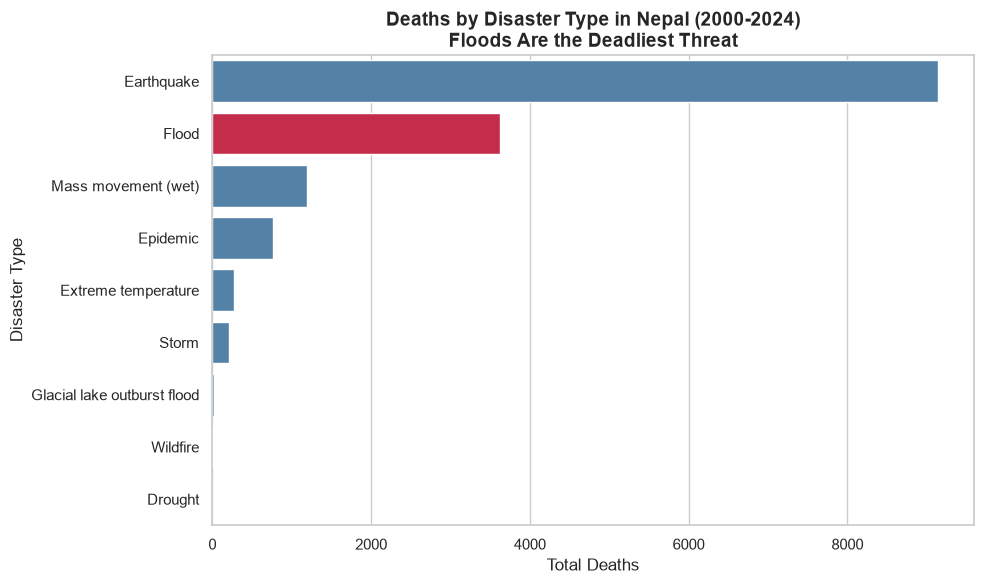

In [21]:
# CHART 5 — All Disaster Types in Nepal
disaster_summary = disasters.groupby('Disaster Type')['Total Deaths'].sum()
disaster_summary = disaster_summary.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['crimson' if x == 'Flood' else 'steelblue' 
          for x in disaster_summary.index]

sns.barplot(x=disaster_summary.values, 
            y=disaster_summary.index,
            palette=colors, ax=ax)

ax.set_title('Deaths by Disaster Type in Nepal (2000-2024)\nFloods Are the Deadliest Threat',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Total Deaths', fontsize=12)
ax.set_ylabel('Disaster Type', fontsize=12)
plt.tight_layout()
plt.savefig('visuals/disaster_types.png', dpi=150)
plt.show()

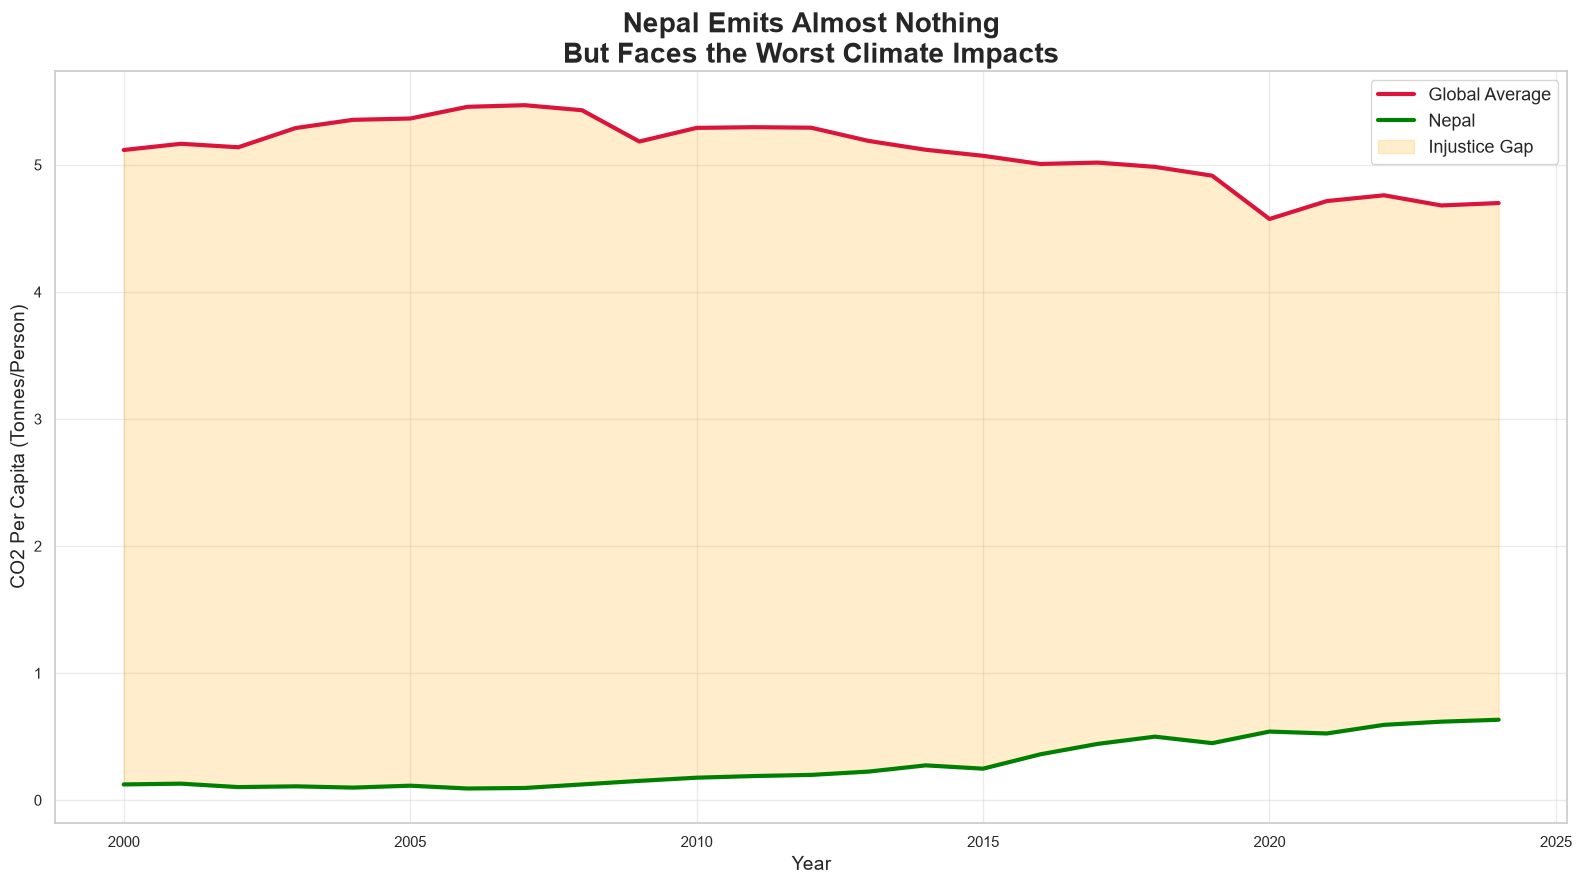

C:\Users\baibh\AppData\Local\Temp\ipykernel_15300\4212467317.py:33: UserWarning: Glyph 127475 (\N{REGIONAL INDICATOR SYMBOL LETTER N}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\baibh\AppData\Local\Temp\ipykernel_15300\4212467317.py:34: UserWarning: Glyph 127475 (\N{REGIONAL INDICATOR SYMBOL LETTER N}) missing from font(s) Arial.
  plt.savefig('visuals/ig_slide2.png', dpi=120)
c:\Users\baibh\OneDrive\Desktop\climate-justice-analysis\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 127475 (\N{REGIONAL INDICATOR SYMBOL LETTER N}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


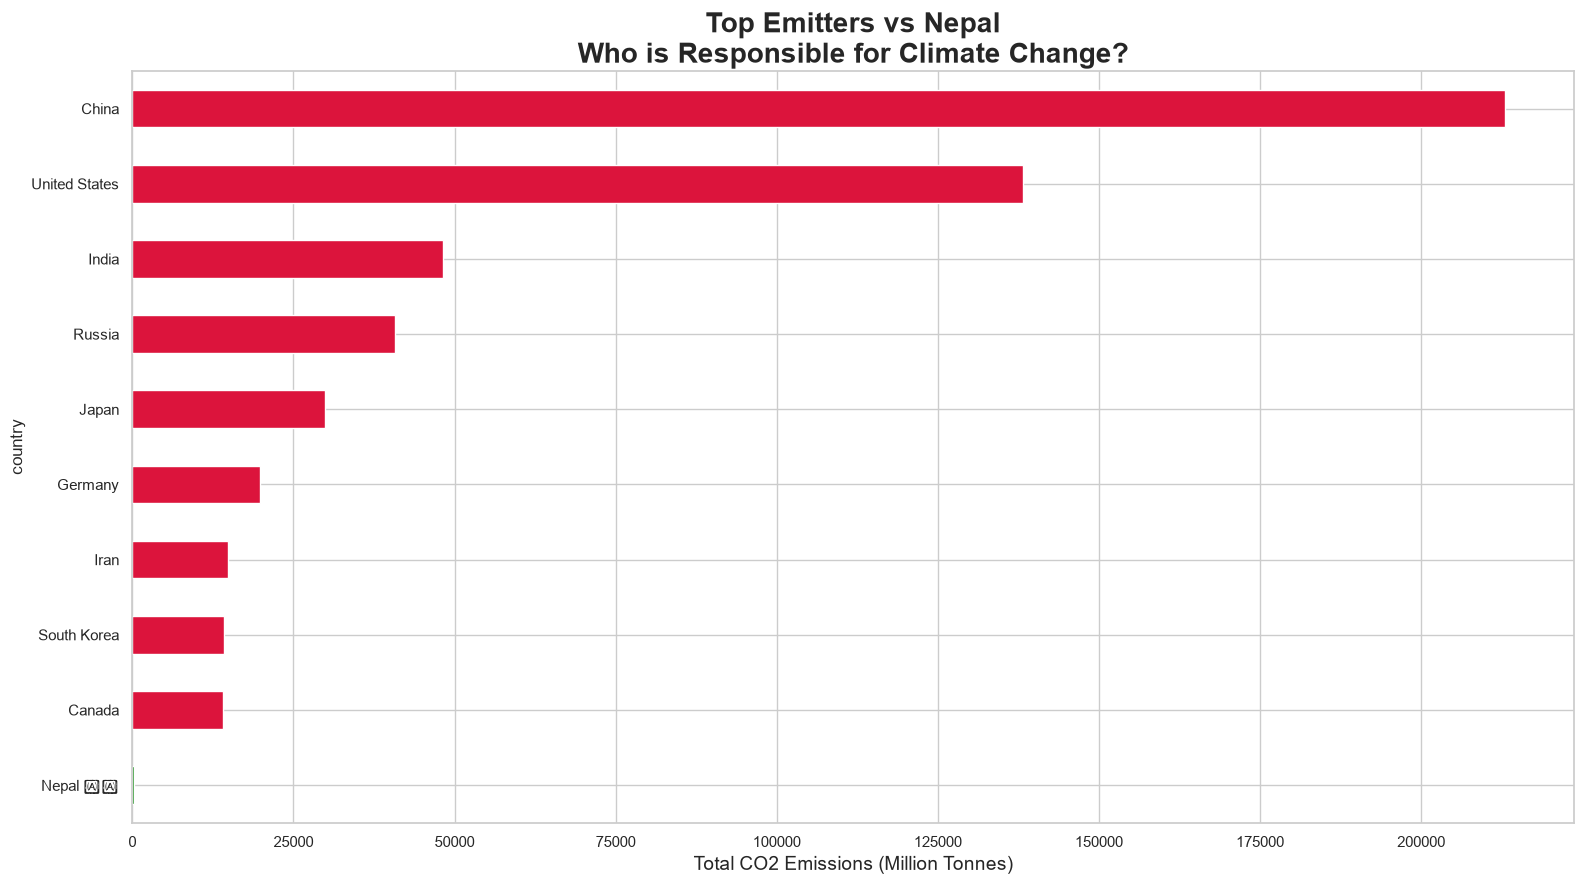

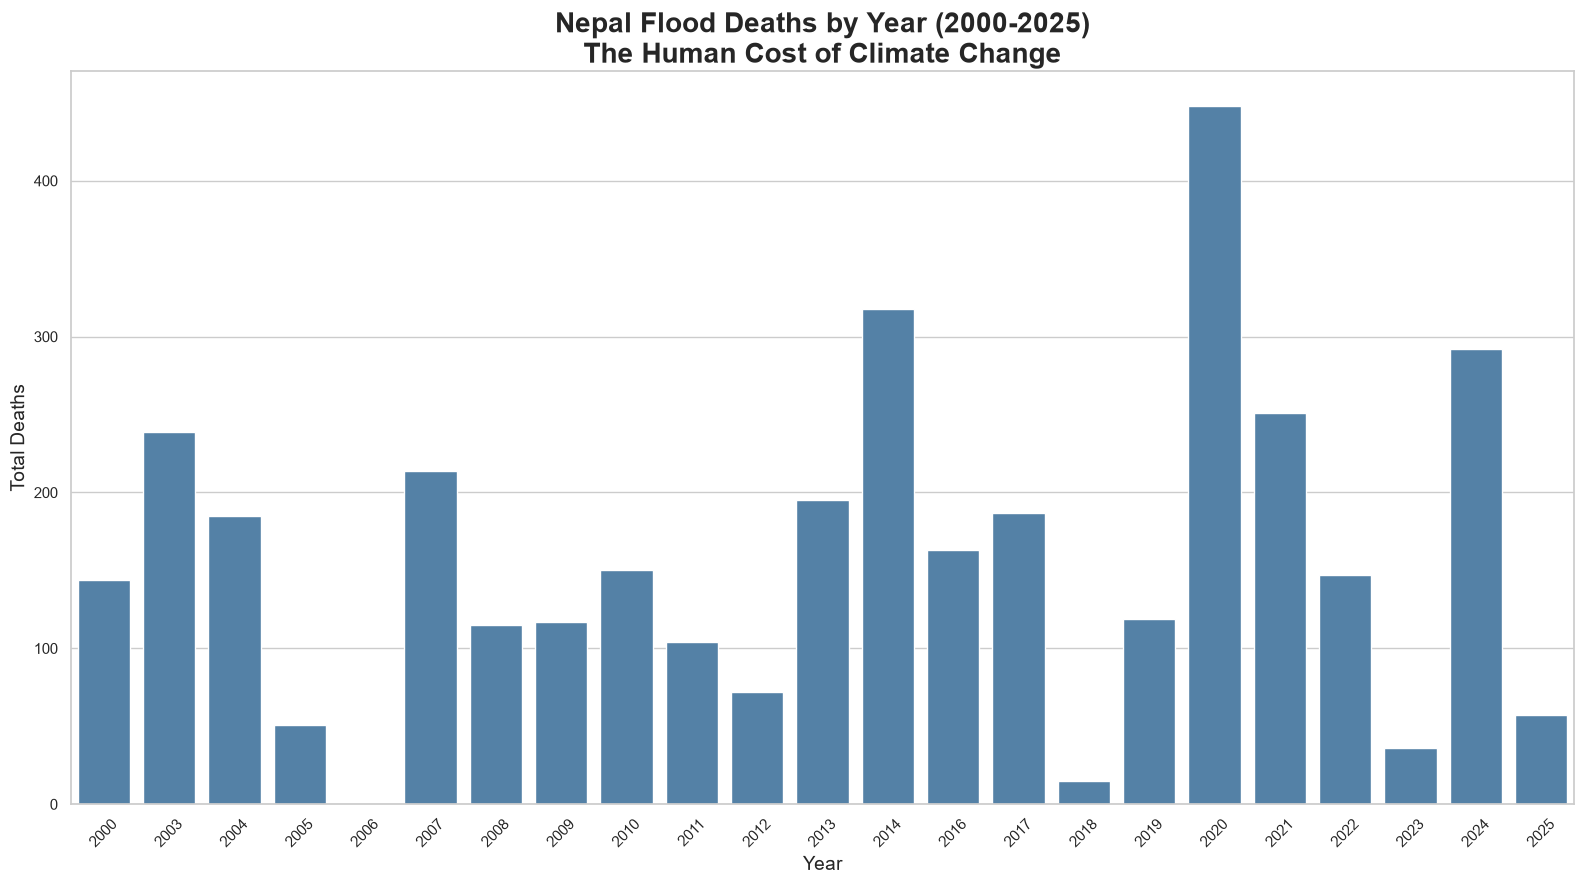

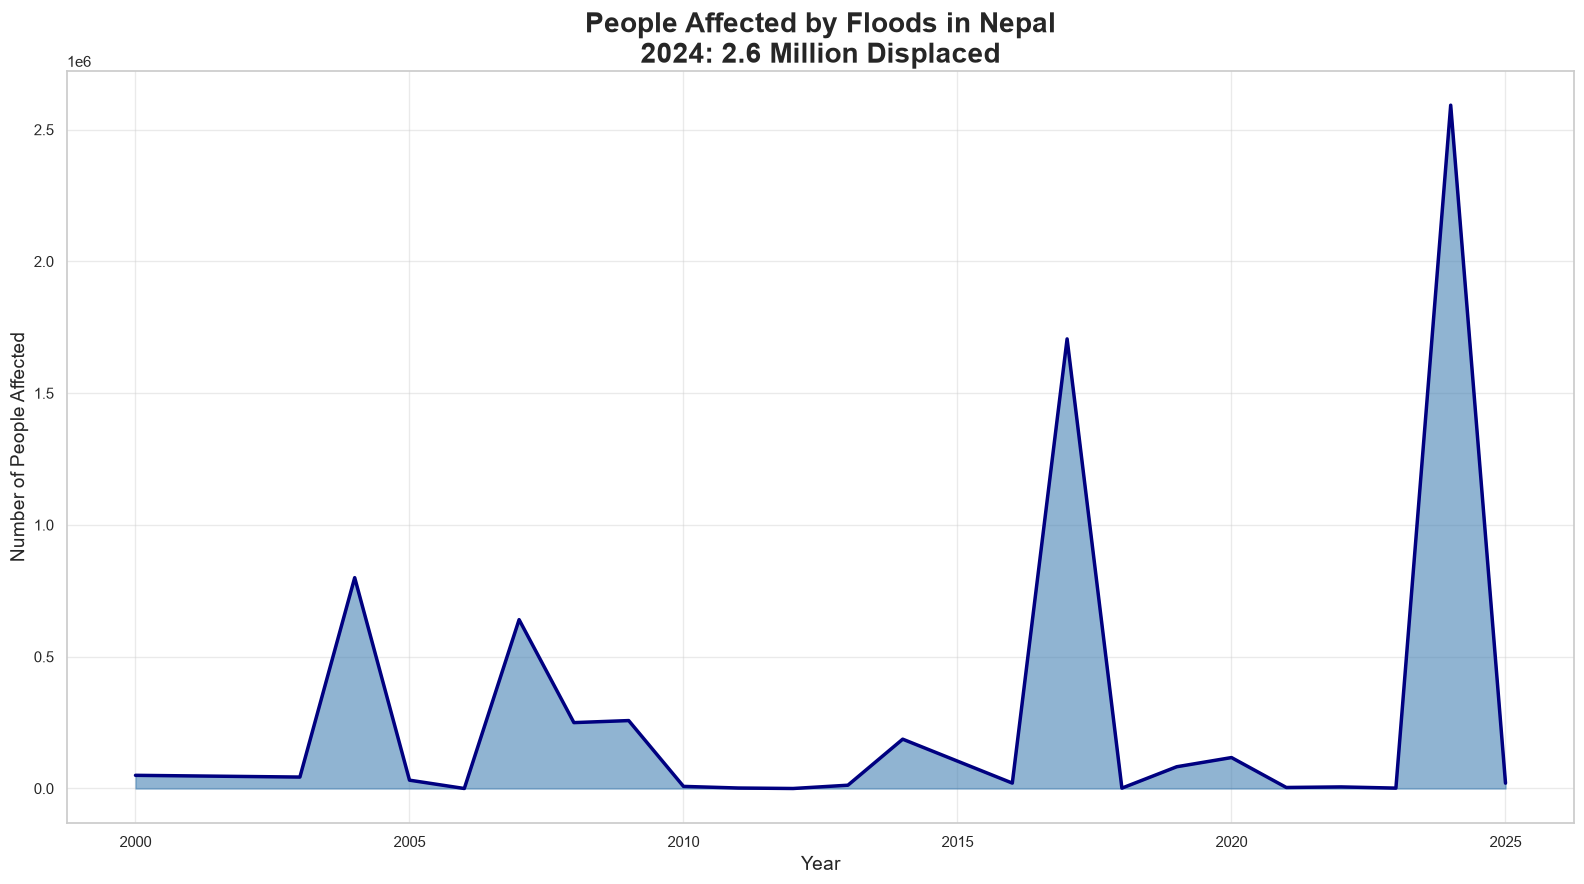

C:\Users\baibh\AppData\Local\Temp\ipykernel_15300\4212467317.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=disaster_summary.values,


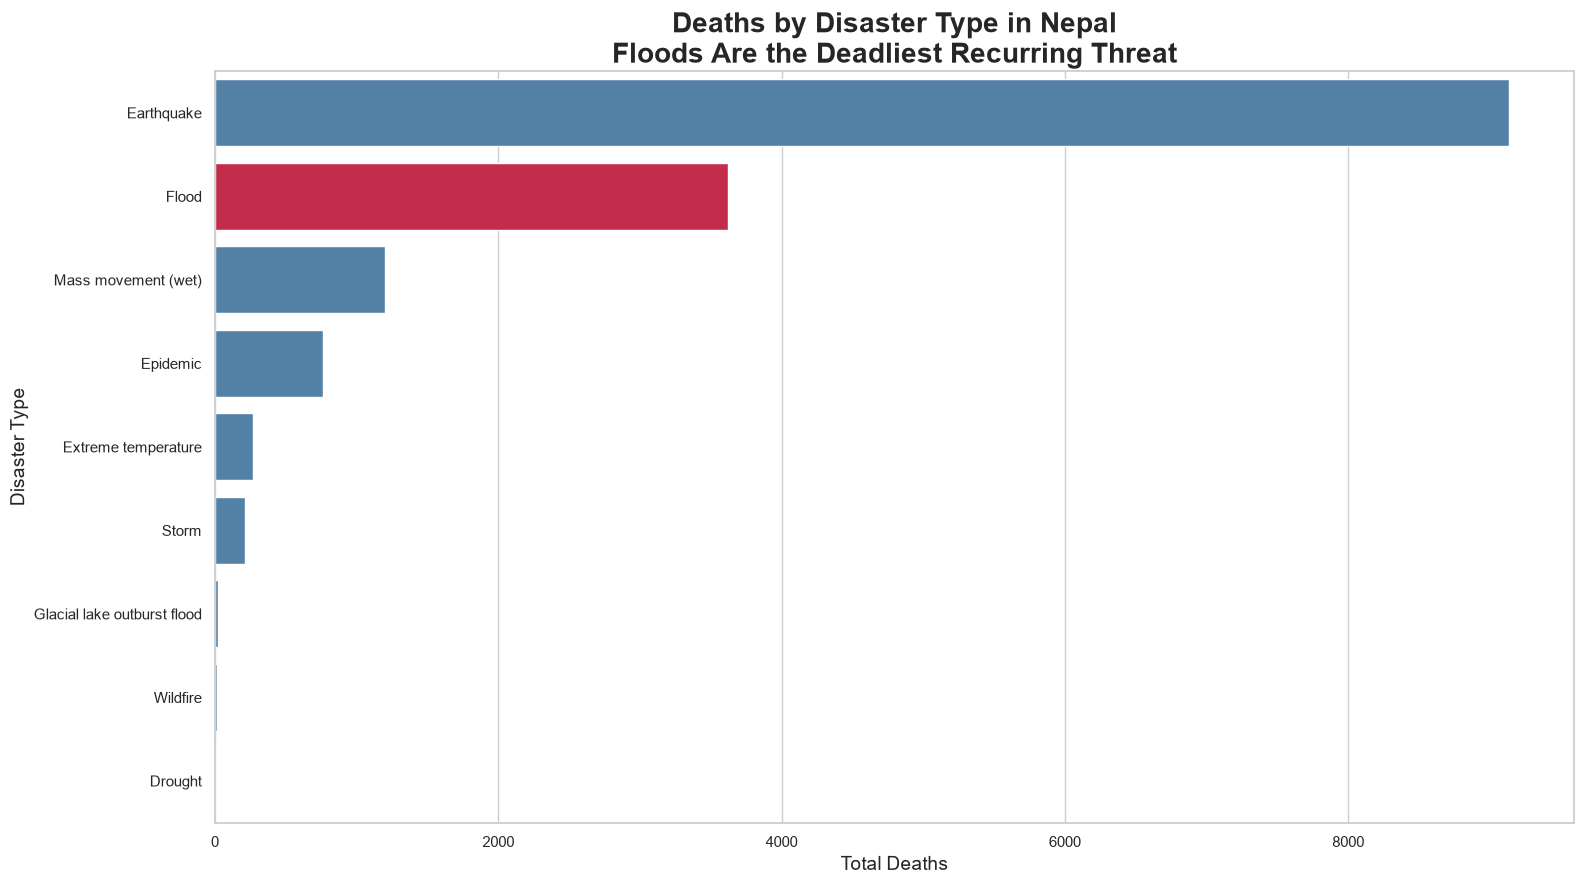

In [22]:
# IG FORMAT — 16:9 (1920x1080) for all charts
fig_size = (16, 9)

# SLIDE 1 — Injustice Gap
fig, ax = plt.subplots(figsize=fig_size)
ax.plot(global_avg['year'], global_avg['co2_per_capita'],
        color='crimson', linewidth=3, label='Global Average')
nepal_co2_filtered = nepal_co2[nepal_co2['year'] >= 2000]
ax.plot(nepal_co2_filtered['year'], nepal_co2_filtered['co2_per_capita'],
        color='green', linewidth=3, label='Nepal')
ax.fill_between(nepal_co2_filtered['year'],
                nepal_co2_filtered['co2_per_capita'],
                global_avg['co2_per_capita'],
                alpha=0.2, color='orange', label='Injustice Gap')
ax.set_title("Nepal Emits Almost Nothing\nBut Faces the Worst Climate Impacts",
             fontsize=20, fontweight='bold')
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('CO2 Per Capita (Tonnes/Person)', fontsize=14)
ax.legend(fontsize=13)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('visuals/ig_slide1.png', dpi=120)
plt.show()

# SLIDE 2 — Top Emitters vs Nepal
fig, ax = plt.subplots(figsize=fig_size)
colors = ['green' if x == 'Nepal 🇳🇵' else 'crimson'
          for x in comparison.index]
comparison.plot(kind='barh', color=colors, ax=ax)
ax.set_title('Top Emitters vs Nepal\nWho is Responsible for Climate Change?',
             fontsize=20, fontweight='bold')
ax.set_xlabel('Total CO2 Emissions (Million Tonnes)', fontsize=14)
plt.tight_layout()
plt.savefig('visuals/ig_slide2.png', dpi=120)
plt.show()

# SLIDE 3 — Flood Deaths
flood_deaths = floods.groupby('Start Year')['Total Deaths'].sum().reset_index()
fig, ax = plt.subplots(figsize=fig_size)
sns.barplot(data=flood_deaths, x='Start Year',
            y='Total Deaths', color='steelblue', ax=ax)
ax.set_title('Nepal Flood Deaths by Year (2000-2025)\nThe Human Cost of Climate Change',
             fontsize=20, fontweight='bold')
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Total Deaths', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visuals/ig_slide3.png', dpi=120)
plt.show()

# SLIDE 4 — People Affected
flood_affected = floods.groupby('Start Year')['No. Affected'].sum().reset_index().dropna()
fig, ax = plt.subplots(figsize=fig_size)
ax.fill_between(flood_affected['Start Year'],
                flood_affected['No. Affected'],
                alpha=0.6, color='steelblue')
ax.plot(flood_affected['Start Year'],
        flood_affected['No. Affected'],
        color='navy', linewidth=2.5)
ax.set_title('People Affected by Floods in Nepal\n2024: 2.6 Million Displaced',
             fontsize=20, fontweight='bold')
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Number of People Affected', fontsize=14)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('visuals/ig_slide4.png', dpi=120)
plt.show()

# SLIDE 5 — Disaster Types
disaster_summary = disasters.groupby('Disaster Type')['Total Deaths'].sum()
disaster_summary = disaster_summary.sort_values(ascending=False)
fig, ax = plt.subplots(figsize=fig_size)
colors_d = ['crimson' if x == 'Flood' else 'steelblue'
            for x in disaster_summary.index]
sns.barplot(x=disaster_summary.values,
            y=disaster_summary.index,
            palette=colors_d, ax=ax)
ax.set_title('Deaths by Disaster Type in Nepal\nFloods Are the Deadliest Recurring Threat',
             fontsize=20, fontweight='bold')
ax.set_xlabel('Total Deaths', fontsize=14)
ax.set_ylabel('Disaster Type', fontsize=14)
plt.tight_layout()
plt.savefig('visuals/ig_slide5.png', dpi=120)
plt.show()